## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [6]:
# TODO: drop the Customer ID column  
df_new = df.drop(columns=('Customer ID'))
df_new.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [7]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [8]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [9]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [10]:
# TODO: univariate — describe numeric columns
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [15]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']


In [16]:
male_df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [17]:
female_df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2652,2653,23,Female,Shorts,Clothing,20,Maryland,L,Cyan,Summer,3.3,No,Debit Card,2-Day Shipping,No,No,46,Credit Card,Monthly
2653,2654,67,Female,Blouse,Clothing,36,Wisconsin,L,Lavender,Fall,4.8,No,Credit Card,Express,No,No,24,Venmo,Every 3 Months
2654,2655,23,Female,Coat,Outerwear,70,Idaho,S,Pink,Fall,4.1,No,Debit Card,Next Day Air,No,No,4,PayPal,Annually
2655,2656,26,Female,Sunglasses,Accessories,83,Wyoming,M,Gray,Summer,3.4,No,Credit Card,Standard,No,No,2,Credit Card,Fortnightly
2656,2657,52,Female,Shorts,Clothing,76,Indiana,L,Yellow,Winter,3.6,No,Bank Transfer,Express,No,No,29,Bank Transfer,Fortnightly


## **EDA**

### **Item Purchased**

In [22]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
count_male_item = df[df['Gender'] == 'Male']['Item Purchased'].value_counts().reset_index()
count_female_item = df[df['Gender'] == 'Female']['Item Purchased'].value_counts().reset_index()
all_cus_item = df['Item Purchased'].value_counts().reset_index()
print('Male')
print(count_male_item.head())
print('Female')
print(count_female_item.head())
print('All')
print(all_cus_item.head())


Male
  Item Purchased  count
0          Pants    123
1        Jewelry    119
2        Sweater    114
3           Coat    114
4          Dress    114
Female
  Item Purchased  count
0         Blouse     66
1        Sandals     59
2          Shirt     59
3        Handbag     58
4          Socks     58
All
  Item Purchased  count
0         Blouse    171
1          Pants    171
2        Jewelry    171
3          Shirt    169
4          Dress    166


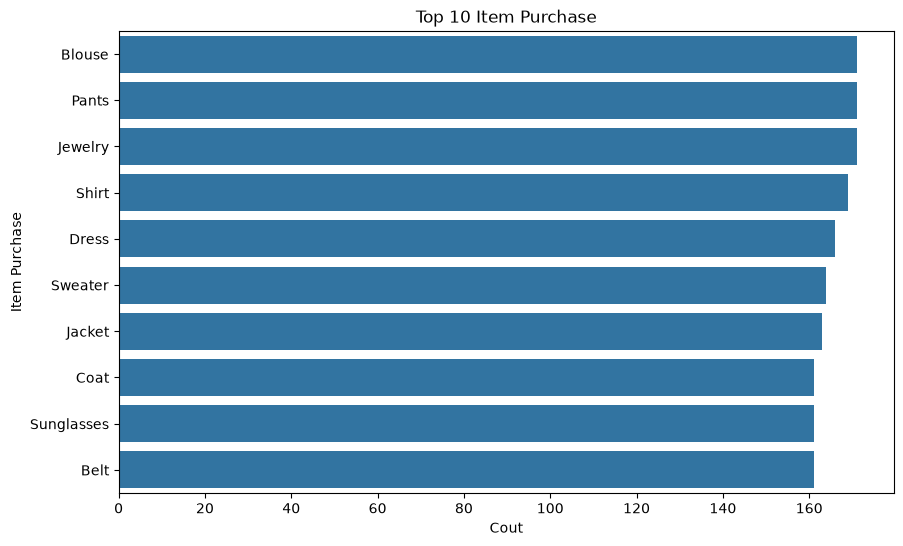

In [28]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
top10 = df['Item Purchased'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top10.values,
    y= top10.index,
    legend= True
)
plt.title('Top 10 Item Purchase')
plt.xlabel('Cout')
plt.ylabel('Item Purchase')
plt.show()

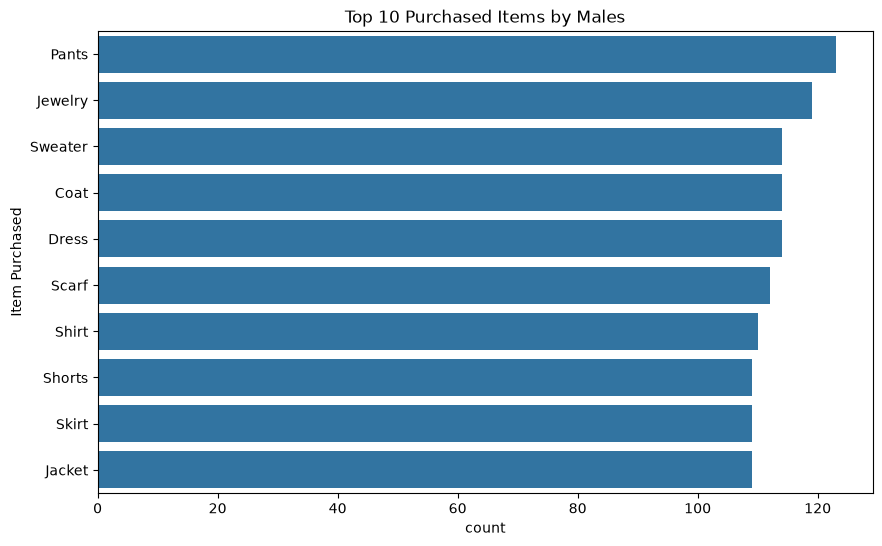

In [33]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
top10_male_itempuchase = df[df['Gender'] == 'Male']['Item Purchased'].value_counts().nlargest(10) 
plt.figure(figsize=(10, 6))
sns.barplot(
    x = top10_male_itempuchase.values,
    y = top10_male_itempuchase.index,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

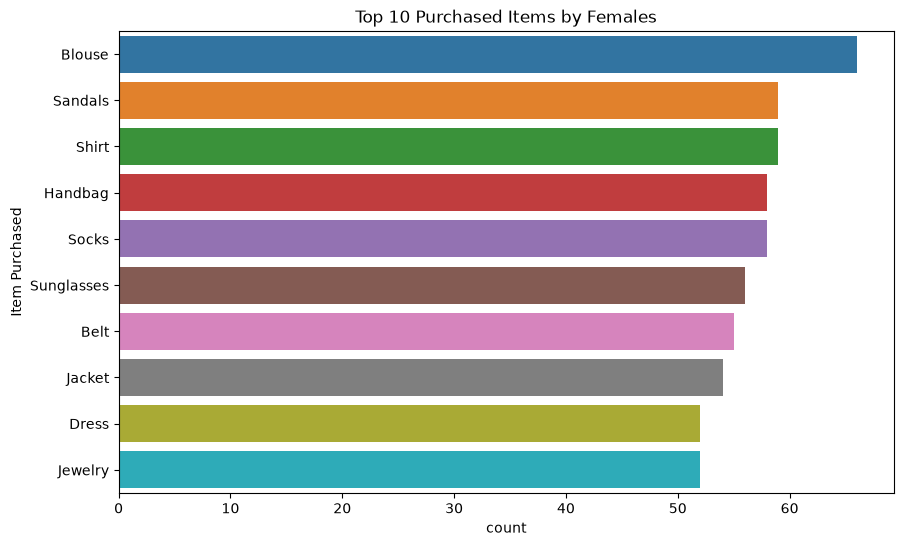

In [36]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
top_item_f = df[df['Gender'] == 'Female']['Item Purchased'].value_counts().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [40]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts().reset_index()

,Size,count
0,M,1755
1,L,1053
2,S,663
3,XL,429


In [42]:
# TODO: count Size with value_counts() for male_df and female_df
female_df['Size'].value_counts().reset_index()

,Size,count
0,M,590
1,L,337
2,S,187
3,XL,134


In [41]:
# TODO: count Size with value_counts() for male_df and female_df
male_df['Size'].value_counts().reset_index()

,Size,count
0,M,1165
1,L,716
2,S,476
3,XL,295


### **Category**

In [43]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1737
1,Accessories,1240
2,Footwear,599
3,Outerwear,324


In [45]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg  = male_df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,1181
1,Accessories,848
2,Footwear,400
3,Outerwear,223


In [46]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg  = female_df['Category'].value_counts().reset_index()
ctg

,Category,count
0,Clothing,556
1,Accessories,392
2,Footwear,199
3,Outerwear,101


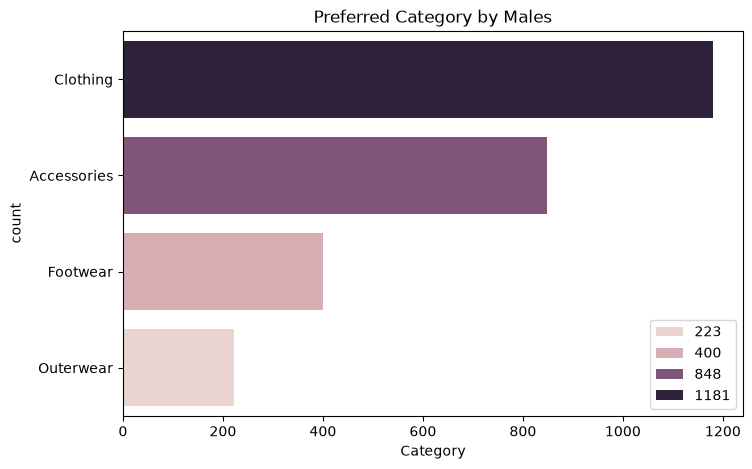

In [47]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
ctg_m = male_df['Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
    x = ctg_m.values,
    y = ctg_m.index,
    hue= ctg_m.values
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

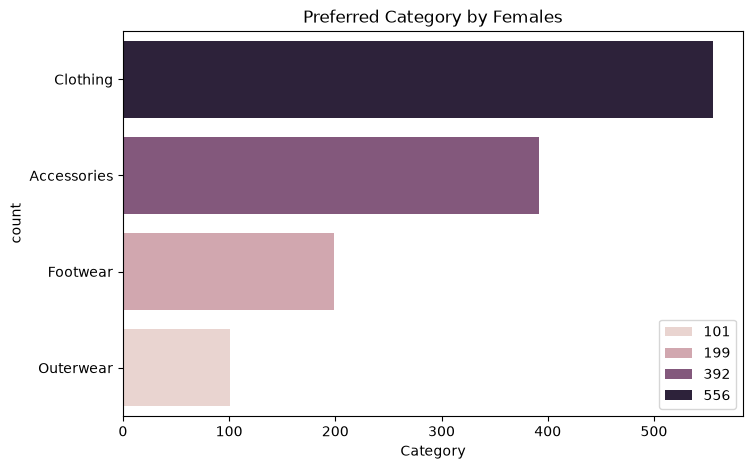

In [48]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
ctg_f  = female_df['Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(
   x = ctg_f.values,
   y = ctg_f.index,
   hue=ctg_f.values
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

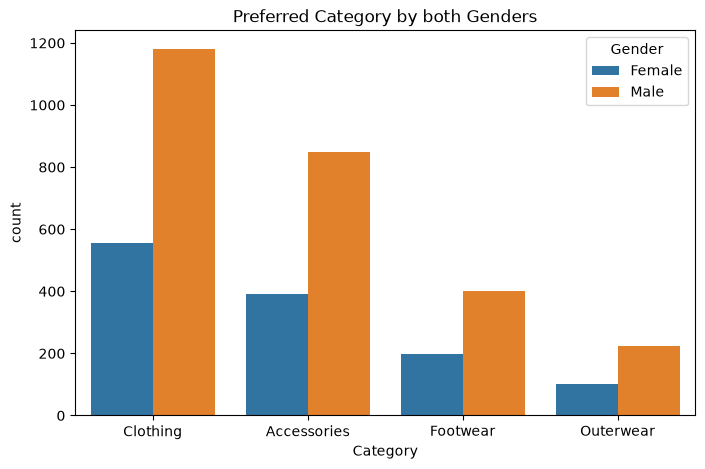

In [64]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_m['Gender'] = 'Male'

ctg_f = female_df['Category'].value_counts().reset_index()
ctg_f['Gender'] = 'Female'

ctg = pd.concat([ctg_f, ctg_m])
ctg['Category'].value_counts().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Gender',
    # dodge=False,
    # legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [ ]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())



In [ ]:
waffle_data_f

{'Clothing': np.int64(556),
 'Accessories': np.int64(392),
 'Footwear': np.int64(199),
 'Outerwear': np.int64(101)}

In [68]:
waffle_data_m

{'Clothing': np.int64(1181),
 'Accessories': np.int64(848),
 'Footwear': np.int64(400),
 'Outerwear': np.int64(223)}

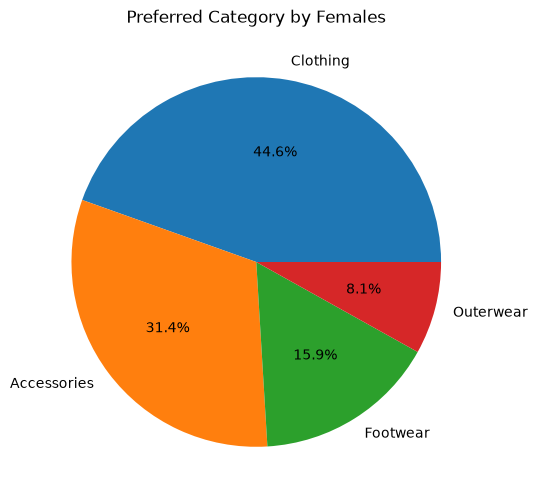

In [71]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()

plt.figure(figsize=(6, 6))
plt.pie(
   female_df['Category'].value_counts(),
   labels= female_df['Category'].value_counts().index,
   autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

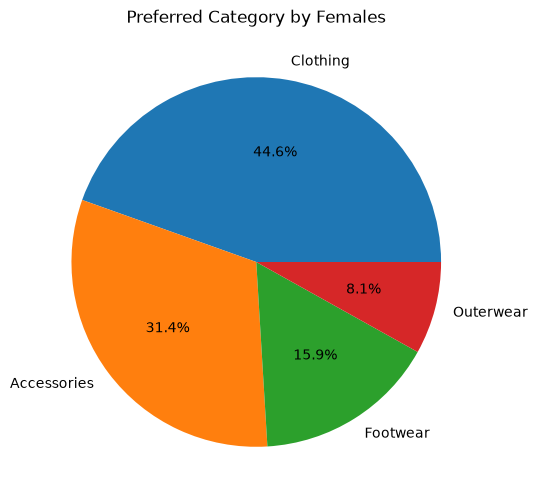

In [73]:
plt.figure(figsize=(6, 6))
plt.pie(
   waffle_data_f.values(),
   labels= waffle_data_f.keys(),
   autopct= '%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

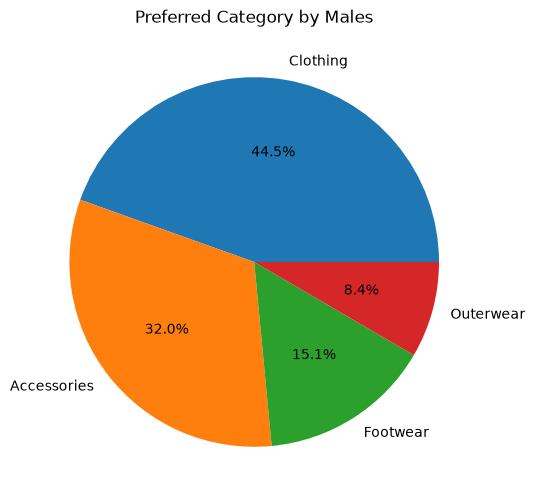

In [72]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [74]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()
print(avg_cr_f)

3.7044964028776977


In [79]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()
print(avg_cr_m)

3.7319220999153258


In [80]:
avg_cr_m,avg_cr_f

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

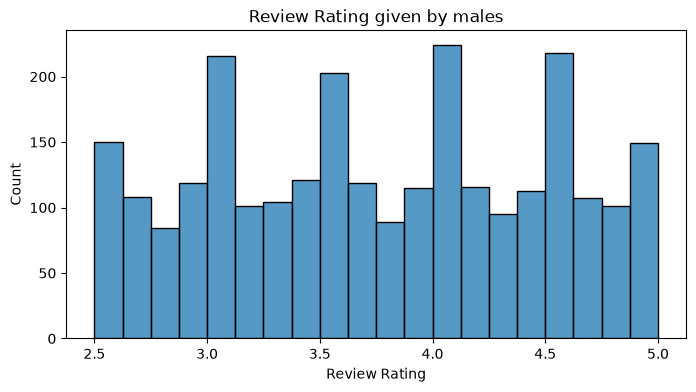

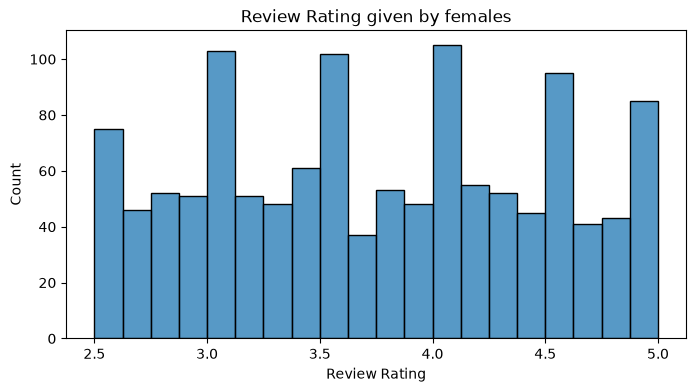

In [81]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title('Review Rating given by females')
plt.show()

In [ ]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [83]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()

# TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

In [86]:
print('m_tpa: ', m_tpa)
print('f_tpa: ', f_tpa)

m_tpa:  157890
f_tpa:  75191


In [96]:
tpa = df[['Gender', 'Purchase Amount (USD)']]
tpa = tpa.groupby('Gender').agg(
     Total_Spend = ('Purchase Amount (USD)', 'sum')
    )
tpa

,Total_Spend
Gender,
Female,75191
Male,157890


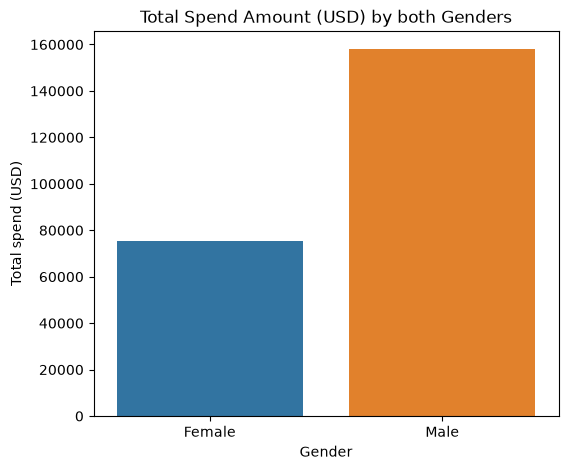

In [100]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    x = tpa.index,
    y = tpa['Total_Spend'],
    hue=tpa.index,
    dodge=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [102]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category']=='Footwear']
co_f = female_df[female_df['Category']=='Outerwear']

In [ ]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']

In [103]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [104]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())

In [105]:
print(pcu)

{'No': np.int64(2223), 'Yes': np.int64(1677)}


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

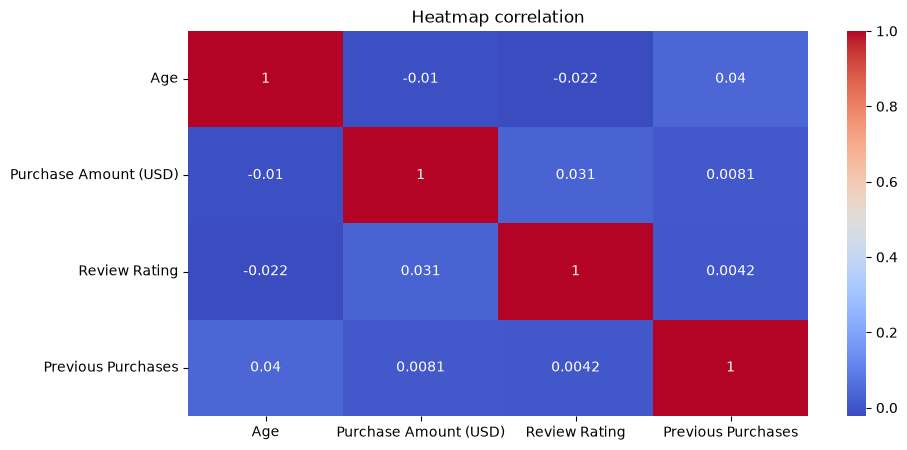

In [114]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].corr(numeric_only=True)
plt.figure(figsize=(10,5))
sns.heatmap(corr, annot= True, cmap='coolwarm')
plt.title("Heatmap correlation")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [121]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender','Size','Category'], dtype=bool)


KeyError: "None of [Index(['Gender', 'Size', 'Category'], dtype='str')] are in the [columns]"

In [122]:
df.head()

,Customer ID,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,1,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,...,False,True,True,False,False,False,False,True,False,False
1,2,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,...,False,True,True,False,False,False,False,True,False,False
2,3,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,...,False,True,False,False,True,False,False,True,False,False
3,4,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,...,False,True,False,True,False,False,False,False,True,False
4,5,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,...,False,True,False,True,False,False,False,True,False,False


In [123]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minmax = MinMaxScaler()
df['Amount_minmax'] = minmax.fit_transform(
    df[['Purchase Amount (USD)']]
).ravel()
standard = StandardScaler()
df['Age_standard'] = standard.fit_transform(
    df[['Age']]
).ravel()
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [125]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(df['Purchase Amount (USD)'], bins=3, labels=['Low', 'Medium', 'High'])
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Sở thích mua sản phẩm khác nhau giữa nam và nữ: Nam giới mua Pants (quần) nhiều nhất, trong khi nữ giới mua Blouse (áo) nhiều nhất.
- Clothing là danh mục được mua nhiều nhất ở cả hai giới, tiếp theo là Accessories.
- Nam giới có tổng số tiền chi tiêu cao hơn nữ giới: nam chi 157.890 USD, trong khi nữ chi 75.191 USD.
- Điểm đánh giá giữa hai giới khá tương đồng. Ví dụ, với danh mục Clothing, điểm đánh giá trung bình của nam khoảng 3,73, còn nữ khoảng 3,70.
- Khách hàng có cả sử dụng và không sử dụng mã khuyến mãi, vì vậy biểu đồ Promo Code Used cho thấy mức độ sử dụng mã khuyến mãi của khách hàng.

Caveat: correlation is not causation.